#### 1.Survival Analysis Homework

Several hurricanes struck the gulf area and resulted in severe casualty and property damage. One of the major defenses is to maintain and coordinate the pump operations during a critical 48 hour period (or over 4 high tides). The Steering Committee of the Center for Risk Management (hereafter the “Committee”) is conducting an analysis for the pump stations in the gulf coast area to help better prepare for future hurricanes.

 

Pumps may or may not fail during a hurricane. If they fail, flood waters begin to rise too quickly which leads to catastrophic damage to homes and businesses in the area and severe loss of life. Pumps can fail for a variety of reasons during a hurricane. The four currently tracked by the Committee are the following:

1.       Flood – overflow or accumulation of an expanse of water that submerges the pump station.

2.       Motor – mechanical failure of the pump motor.

3.       Surge – onshore gush of water usually associated with levee or structural failure.

4.       Jammed – accumulation of trash or landslide materials which leads to water not getting to the pump.

 

For further information on how New Orleans specifically has adjusted since hurricane Katrina with the upgrades of such pumps please see the following article from the Wall Street Journal: https://www.wsj.com/articles/how-new-orleans-fortified-itself-against-water-11562981176

The data set hurricane contains 770 observations and 59 variables.

All of the pumps have a reason for failure in the variable reason:

      0 – no failure

      1 – flood failure

      2 – motor failure

      3 – surge failure

      4 – jammed failure

There are 56 variables describing the pump’s factors that potentially influence the survivability of the pump stations (not all pumps have each characteristic, but some characteristics are available through upgrade or maintenance).

 

Name

Model Role

Description

AGE

Input

Difference between the installation and the current date

BACKUP

 

Input

Redundant system used to protect the station from flooding when the main pump is not operating

(UPGRADE AVAILABLE – $100K)

BRIDGECRANE

 

Input

Allow vertical access to equipment and protecting materials

(UPGRADE AVAILABLE – $50K)

ELEVATION

 

Input

Elevation of the pump station that can be altered by 1 foot by maintenance

(MAINTANENCE AVAILABLE – $10K/FT)

GEAR

Input

Gear box used to make the pumps stronger and faster

(UPGRADE AVAILABLE – $75K)

H1 – H48

 

Input

Pumping status during a 48 hour emergency reported by pump stations – accuracy of pump status not

guaranteed to be error free

HOUR

Target

Hour that the pump failed or was censored

REASON

Strata

Reason for pump failure

(recorded as 0, 1, 2, 3, or 4)

 

SERVO

 

Input

Servomechanism is used to provide control of a desired operation through the Supervisory control and data acquisition (SCADA) system

(UPGRADE AVAILABLE – $150K)

SLOPE

Input

Surrounding ravine slope of the pump station

SURVIVE

Target

If the pump survived the hurricane without failure

TRASHRACK

 

Input

Used for protecting hydraulic structures against the inlet of debris, of vegetation, urban or industrial trash

(UPGRADE AVAILABLE – $80K)

AA 502 (100) Fall 2024 Analytics Methods and Applications I

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("hurricane.csv")
df.shape

(770, 60)

In [28]:
df.tail(25)

,backup,age,bridgecrane,servo,gear,trashrack,slope,elevation,h1,h2,...,h43,h44,h45,h46,h47,h48,survive,hour,reason,reason2
745,0,6.8,0,1,0,1,4,3,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,26,4,4
746,0,6.9,0,1,0,0,3,2,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,24,4,4
747,0,6.9,1,0,0,1,18,3,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,12,4,4
748,0,7.0,1,0,0,1,3,2,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0,11,4,4
749,1,7.1,1,1,0,0,4,3,1,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,25,4,4
750,1,7.1,1,0,0,1,4,3,0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0,27,4,4
751,0,7.2,1,1,1,1,2,2,1,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0,26,4,4
752,1,7.2,1,1,0,0,10,3,0,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0,26,4,4
753,0,7.3,1,1,0,1,3,2,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,27,4,4
754,0,7.5,1,1,0,0,4,2,0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,25,4,4


In [9]:
df.describe()

,backup,age,bridgecrane,servo,gear,trashrack,slope,elevation,h1,h2,...,h43,h44,h45,h46,h47,h48,survive,hour,reason,reason2
count,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,768.000000,...,618.000000,610.000000,608.000000,604.000000,598.000000,597.000000,770.000000,770.000000,770.000000,770.000000
mean,0.493506,7.226753,0.870130,0.596104,0.129870,0.516883,3.149351,3.388312,0.148052,0.278646,...,0.522654,0.524590,0.524671,0.529801,0.541806,0.534338,0.410390,38.520779,1.475325,3.527273
std,0.500283,1.026241,0.336379,0.490996,0.336379,0.500040,2.998444,0.849458,0.355382,0.448625,...,0.499891,0.499805,0.499802,0.499525,0.498666,0.499238,0.492224,12.891170,1.505098,1.503324
min,0.000000,5.300000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000,6.500000,1.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000,0.000000,2.000000
50%,0.000000,7.000000,1.000000,1.000000,0.000000,1.000000,2.000000,3.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,45.000000,1.000000,4.000000
75%,1.000000,7.800000,1.000000,1.000000,0.000000,1.000000,4.000000,4.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,48.000000,3.000000,5.000000
max,1.000000,10.400000,1.000000,1.000000,1.000000,1.000000,18.000000,6.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,48.000000,4.000000,5.000000


In [10]:
df.columns

Index(['backup', 'age', 'bridgecrane', 'servo', 'gear', 'trashrack', 'slope',
       'elevation', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'h7', 'h8', 'h9',
       'h10', 'h11', 'h12', 'h13', 'h14', 'h15', 'h16', 'h17', 'h18', 'h19',
       'h20', 'h21', 'h22', 'h23', 'h24', 'h25', 'h26', 'h27', 'h28', 'h29',
       'h30', 'h31', 'h32', 'h33', 'h34', 'h35', 'h36', 'h37', 'h38', 'h39',
       'h40', 'h41', 'h42', 'h43', 'h44', 'h45', 'h46', 'h47', 'h48',
       'survive', 'hour', 'reason', 'reason2'],
      dtype='object')

In [21]:
df.reason.describe()

count    770.000000
mean       1.475325
std        1.505098
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max        4.000000
Name: reason, dtype: float64

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator
from lifelines import KaplanMeierFitter
from lifelines import NelsonAalenFitter

#build the thing
km = KaplanMeierFitter()

#fit the thing
km.fit(durations = df['hour'],event_observed=df['survive']==0) #Tenure is hour, Censored is survive==0

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 770 total observations, 316 right-censored observations>

In [16]:
km.event_table

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,770,770
1.0,1,1,0,0,770
2.0,2,2,0,0,769
3.0,2,2,0,0,767
4.0,4,4,0,0,765
5.0,4,4,0,0,761
6.0,5,5,0,0,757
7.0,7,7,0,0,752
8.0,3,3,0,0,745


In [18]:
km.survival_function_

,KM_estimate
timeline,
0.0,1.000000
1.0,0.998701
2.0,0.996104
3.0,0.993506
4.0,0.988312
5.0,0.983117
6.0,0.976623
7.0,0.967532
8.0,0.963636


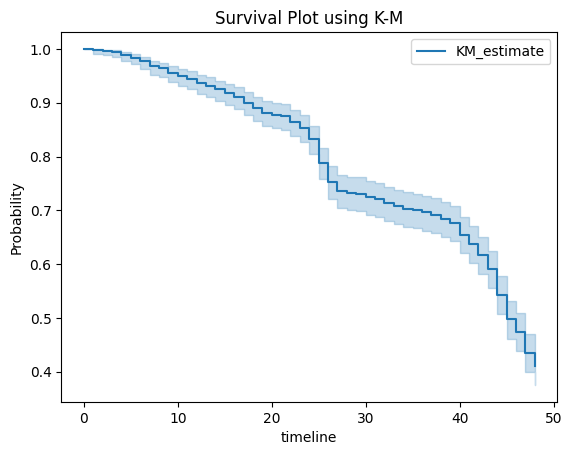

In [19]:
km.plot()
plt.title("Survival Plot using K-M")
plt.ylabel("Probability")
plt.show()

<Axes: xlabel='timeline'>

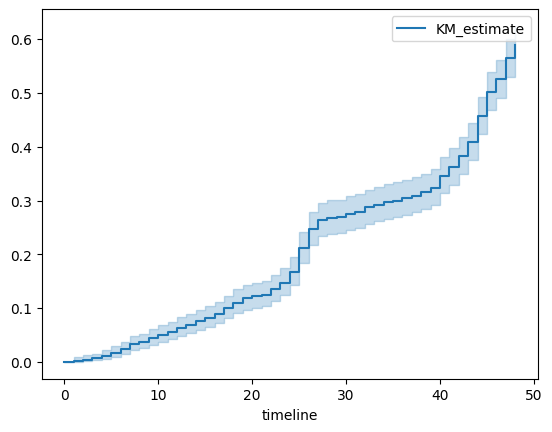

In [20]:
km.plot_cumulative_density()

Stratified Analysis

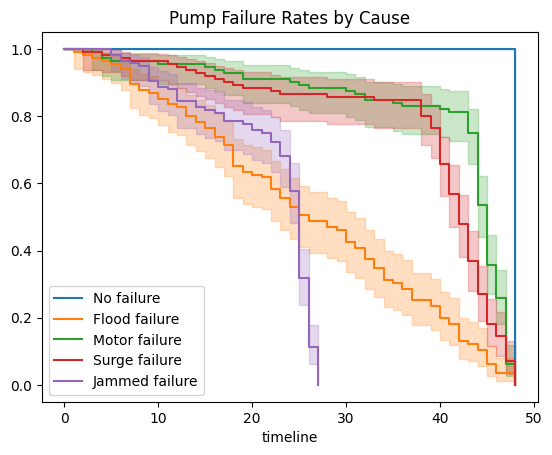

In [22]:
time_fail = df["hour"]

no_failure = (df["reason"]==0)
flood_failure = (df["reason"]==1)
motor_failure = (df["reason"]==2)
surge_failure = (df["reason"]==3)
jammed_failure = (df["reason"]==4)

# Initialize the plot
fig, ax = plt.subplots()

# Kaplan-Meier Fitter instance
kmf = KaplanMeierFitter()

# Fit and plot for failure groups
kmf.fit(time_fail[no_failure], label="No failure")
kmf.plot_survival_function(ax=ax)
# Fit and plot for failure groups
kmf.fit(time_fail[flood_failure], label="Flood failure")
kmf.plot_survival_function(ax=ax)
# Fit and plot for failure groups
kmf.fit(time_fail[motor_failure], label="Motor failure")
kmf.plot_survival_function(ax=ax)
# Fit and plot for failure groups
kmf.fit(time_fail[surge_failure], label="Surge failure")
kmf.plot_survival_function(ax=ax)
# Fit and plot for failure groups
kmf.fit(time_fail[jammed_failure], label="Jammed failure")
kmf.plot_survival_function(ax=ax)

plt.title("Pump Failure Rates by Cause")
plt.show()

In [25]:
## There is also a multivariate_logrank_test for when you have more than two groups to compare and a pairwise_logrank_test to do multiple comparisons.
from lifelines.statistics import logrank_test

results = logrank_test(time_fail[flood_failure], time_fail[motor_failure], time_fail[surge_failure], 
                       time_fail[jammed_failure], weightings="wilcoxon",alpha=.99)

results.print_summary()

<lifelines.StatisticalResult: Wilcoxon_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.99
         test_name = Wilcoxon_test

---
 test_statistic      p  -log2(p)
          81.68 <0.005     62.44

Failure Rates by Pump Type

In [27]:
no_failure_prop = (df["reason"]==0).mean()
flood_failure_prop = (df["reason"]==1).mean()
motor_failure_prop = (df["reason"]==2).mean()
surge_failure_prop = (df["reason"]==3).mean()
jammed_failure_prop = (df["reason"]==4).mean()

print(f"The rate for no failure is {no_failure_prop}")
print(f"The rate for flood failure is  {flood_failure_prop}")
print(f"The rate for motor failure is {motor_failure_prop}")
print(f"The rate for surge failure is {surge_failure_prop}")
print(f"The rate for jammed failure is {jammed_failure_prop}")

The rate for no failure is 0.4103896103896104
The rate for flood failure is  0.14935064935064934
The rate for motor failure is 0.14545454545454545
The rate for surge failure is 0.14415584415584415
The rate for jammed failure is 0.15064935064935064


Mean Time to Failure

In [37]:
failure_rate = 1 - (df['survive'].mean())

mean_time_to_fail = df[(df['survive']==0)]['hour'].mean()
mean_time_flood = df[(df['survive']==0) & (df['reason']==1)]['hour'].mean()
mean_time_motor = df[(df['survive']==0) & (df['reason']==2)]['hour'].mean()
mean_time_surge = df[(df['survive']==0) & (df['reason']==3)]['hour'].mean()
mean_time_jammed = df[(df['survive']==0) & (df['reason']==4)]['hour'].mean()

print(f"The overall failure rate is {failure_rate}")
print(f"\nThe mean time to fail is {mean_time_flood}")
print(f"\nThe mean time to fail for flood failure is  {mean_time_to_fail}")
print(f"\nThe mean time to fail for motor failure is {mean_time_motor}")
print(f"\nThe mean time to fail for surge failure is {mean_time_surge}")
print(f"\nThe mean time to fail for jammed failure is {mean_time_jammed}")

The overall failure rate is 0.5896103896103896

The mean time to fail is 26.443478260869565

The mean time to fail for flood failure is  31.922907488986784

The mean time to fail for motor failure is 41.044642857142854

The mean time to fail for surge failure is 38.828828828828826

The mean time to fail for jammed failure is 21.939655172413794


Proportional Failure Rates

In [59]:
df2.head(25)

,reason,survive,hour
316,1,0,37
317,1,0,33
318,1,0,28
319,1,0,10
320,1,0,26
321,1,0,34
322,1,0,23
323,1,0,37
324,1,0,32
325,1,0,46


In [53]:
df2.tail(25)

,reason,survive,hour
745,4,0,26
746,4,0,24
747,4,0,12
748,4,0,11
749,4,0,25
750,4,0,27
751,4,0,26
752,4,0,26
753,4,0,27
754,4,0,25


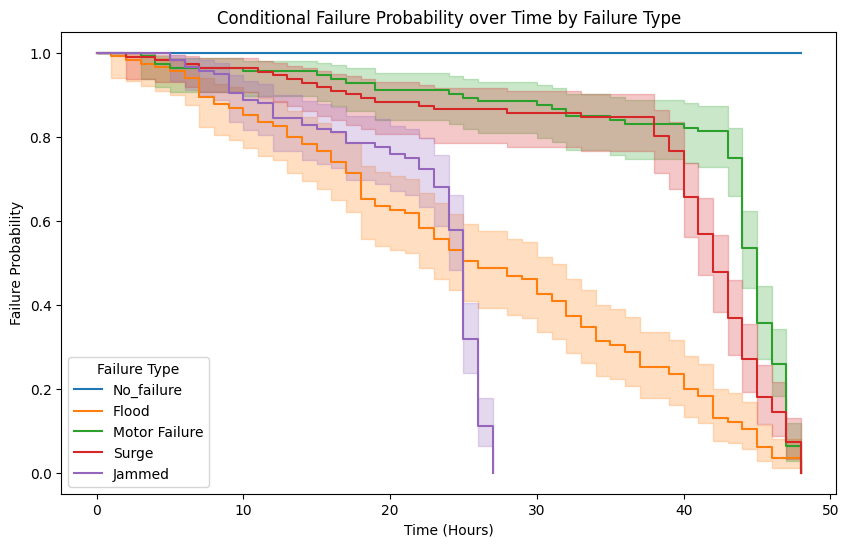

In [86]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Initialize the plot
plt.figure(figsize=(10, 6))

# Define failure types and their labels
failure_types = {
    0: 'No_failure',
    1: 'Flood',
    2: 'Motor Failure',
    3: 'Surge',
    4: 'Jammed'
}

# Loop through each failure type, fit the Kaplan-Meier model, and plot the failure probabilities
for reason, label in failure_types.items():
    df_reason = df[df['reason'] == reason]
    
    # Fit Kaplan-Meier model
    kmf = KaplanMeierFitter()
    kmf.fit(df_reason['hour'], event_observed=(df_reason['survive']==0))
    
    # Plot the failure probability (1 - survival function)
    kmf.plot_survival_function(label=label)
    
# Customize and show the plot
plt.title("Conditional Failure Probability over Time by Failure Type")
plt.xlabel("Time (Hours)")
plt.ylabel("Failure Probability")
plt.legend(title="Failure Type")
plt.show()


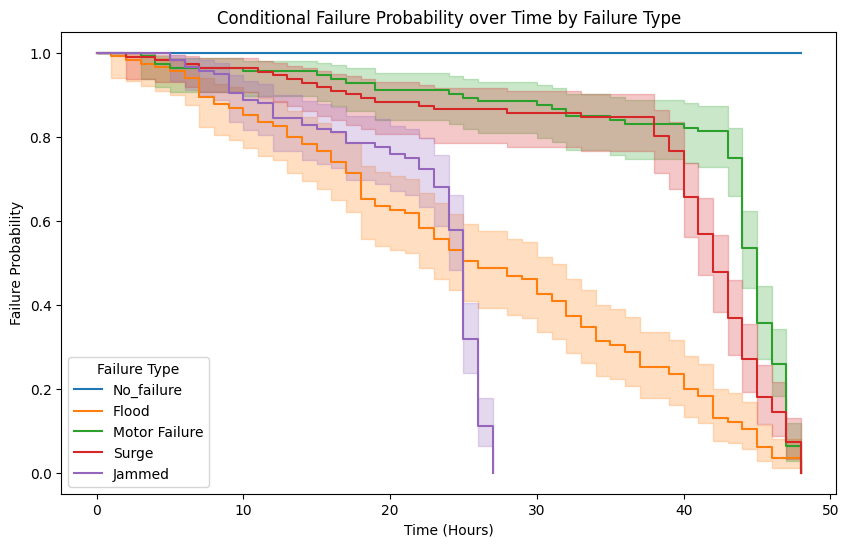

In [60]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Initialize the plot
plt.figure(figsize=(10, 6))

# Define failure types and their labels
failure_types = {
    0: 'No_failure',
    1: 'Flood',
    2: 'Motor Failure',
    3: 'Surge',
    4: 'Jammed'
}

# Loop through each failure type, fit the Kaplan-Meier model, and plot the failure probabilities
for reason, label in failure_types.items():
    df_reason = df[df['reason'] == reason]
    
    # Fit Kaplan-Meier model
    kmf = KaplanMeierFitter()
    
    # 'survive' column is treated as event_observed where 0 means failure (event occurred) and 1 means no failure (censored)
    kmf.fit(df_reason['hour'], event_observed=(df_reason['survive'] == 0))
    
    # Plot the failure probability (1 - survival function)
    kmf.plot_survival_function(label=label)

# Customize and show the plot
plt.title("Conditional Failure Probability over Time by Failure Type")
plt.xlabel("Time (Hours)")
plt.ylabel("Failure Probability")
plt.legend(title="Failure Type")
plt.show()


In [65]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test  # Correct import
import matplotlib.pyplot as plt

# Define failure types and their labels
failure_types = {
    0: 'No_failure',
    1: 'Flood',
    2: 'Motor Failure',
    3: 'Surge',
    4: 'Jammed'
}

# Initialize Kaplan-Meier Fitter
kmf = KaplanMeierFitter()

# Prepare a list to store results of the Log-Rank Test for each pair of failure types
logrank_results = {}

# Loop through each pair of failure types and perform the Log-Rank test
for reason1, label1 in failure_types.items():
    for reason2, label2 in failure_types.items():
        if reason1 < reason2:  # To avoid redundant comparisons
            # Filter the data for each failure type
            df_reason1 = df[df['reason'] == reason1]
            df_reason2 = df[df['reason'] == reason2]
            
            # Perform the Log-Rank test between the two failure types
            results = logrank_test(df_reason1['hour'], df_reason2['hour'], 
                                   event_observed_A=df_reason1['survive'] == 0, 
                                   event_observed_B=df_reason2['survive'] == 0)
            
            # Store the results in the dictionary, including test statistics and p-values
            logrank_results[(label1, label2)] = {
                'test_statistic': results.test_statistic,
                'p_value': results.p_value
            }

# Print the test statistics and p-values of the Log-Rank test for each pair of failure types
for pair, result in logrank_results.items():
    print(f"Log-Rank Test between {pair[0]} and {pair[1]}:")
    print(f"  Test Statistic: {result['test_statistic']:.4f}")
    print(f"  p-value: {result['p_value']:.4f}\n")


Log-Rank Test between No_failure and Flood:
  Test Statistic: 679.7140
  p-value: 0.0000

Log-Rank Test between No_failure and Motor Failure:
  Test Statistic: 621.5528
  p-value: 0.0000

Log-Rank Test between No_failure and Surge:
  Test Statistic: 652.3654
  p-value: 0.0000

Log-Rank Test between No_failure and Jammed:
  Test Statistic: 616.3438
  p-value: 0.0000

Log-Rank Test between Flood and Motor Failure:
  Test Statistic: 76.3501
  p-value: 0.0000

Log-Rank Test between Flood and Surge:
  Test Statistic: 40.7595
  p-value: 0.0000

Log-Rank Test between Flood and Jammed:
  Test Statistic: 26.9418
  p-value: 0.0000

Log-Rank Test between Motor Failure and Surge:
  Test Statistic: 12.1579
  p-value: 0.0005

Log-Rank Test between Motor Failure and Jammed:
  Test Statistic: 172.9566
  p-value: 0.0000

Log-Rank Test between Surge and Jammed:
  Test Statistic: 156.0323
  p-value: 0.0000



#### HW2

Objective

The scope of services includes the following:

- For this phase use the entire data set.
- This phase will only be focused on one type of failure (Flood). (This could easily be replicated for each type, but you are only responsible for failure in this RFP.)
- Build a model with your target variable being the time to flood events.

o (HINT: Censor all observations that are not a Flood failure. In other words, your censor variable is now flood vs. no flood, NOT survive vs not survive. This process is actually called competing risks which we will be discussing later in the course.)

o Use only main effects in this model (No interactions and no H1-H48 variables).

o Select an appropriate distribution for your model using both graphical approaches and
statistical tests.

- Include any graphs or p-values that you use in determining the appropriate
distribution (can be in Appendix).

o Perform variable selection once you have your optimal distribution.

- The Committee currently uses a significance level of 0.03 and backward
selection to choose their models.

- Feel free to use a different significance level and selection technique as long as
you defend your reason.

o Include a table of significant variables ranked by p-value.

o Interpret the effects of the most significant variable.

- Analyze the pumps that failed due to flood failure and evaluate which pumps you would recommend getting an upgrade on the factors you found significant in your model.

o You can only perform one upgrade per pump.

o You have a fixed budget of $2.5 million and must use this money accordingly to keep
pumps functioning as long as possible.

o Provide a list of the pumps (use index number) as well as the upgrades for those
pumps.

- For each pump estimate the time benefit for your upgrade. (HINT: Use a similar approach as we did in class where we analyzed the benefit of giving financial aid to prisoners.)

In [66]:
df.head()

,backup,age,bridgecrane,servo,gear,trashrack,slope,elevation,h1,h2,...,h43,h44,h45,h46,h47,h48,survive,hour,reason,reason2
0,0,6.0,0,0,0,1,3,2,1,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1,48,0,5
1,0,6.0,1,0,0,1,7,3,0,0.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1,48,0,5
2,0,6.1,1,0,0,1,3,3,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,48,0,5
3,1,6.1,1,0,0,0,4,3,1,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,48,0,5
4,0,6.2,1,1,0,1,3,4,1,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,48,0,5


In [104]:
df.shape

(770, 61)

In [72]:
# target variable: time to flood events. Censor observations that are not a Flood event.
df['cen'] = (df['reason']!=1).astype(int)
df.head()

,backup,age,bridgecrane,servo,gear,trashrack,slope,elevation,h1,h2,...,h44,h45,h46,h47,h48,survive,hour,reason,reason2,cen
0,0,6.0,0,0,0,1,3,2,1,1.0,...,1.0,1.0,1.0,1.0,1.0,1,48,0,5,1
1,0,6.0,1,0,0,1,7,3,0,0.0,...,1.0,1.0,1.0,1.0,0.0,1,48,0,5,1
2,0,6.1,1,0,0,1,3,3,0,0.0,...,0.0,0.0,0.0,0.0,0.0,1,48,0,5,1
3,1,6.1,1,0,0,0,4,3,1,1.0,...,0.0,0.0,0.0,0.0,0.0,1,48,0,5,1
4,0,6.2,1,1,0,1,3,4,1,1.0,...,0.0,0.0,0.0,0.0,0.0,1,48,0,5,1


In [76]:
df.columns

Index(['backup', 'age', 'bridgecrane', 'servo', 'gear', 'trashrack', 'slope',
       'elevation', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'h7', 'h8', 'h9',
       'h10', 'h11', 'h12', 'h13', 'h14', 'h15', 'h16', 'h17', 'h18', 'h19',
       'h20', 'h21', 'h22', 'h23', 'h24', 'h25', 'h26', 'h27', 'h28', 'h29',
       'h30', 'h31', 'h32', 'h33', 'h34', 'h35', 'h36', 'h37', 'h38', 'h39',
       'h40', 'h41', 'h42', 'h43', 'h44', 'h45', 'h46', 'h47', 'h48',
       'survive', 'hour', 'reason', 'reason2', 'cen'],
      dtype='object')

In [106]:
df.isna().mean().sort_values(ascending=False)

h48            0.224675
h47            0.223377
h46            0.215584
h45            0.210390
h44            0.207792
                 ...   
trashrack      0.000000
gear           0.000000
servo          0.000000
bridgecrane    0.000000
cen            0.000000
Length: 61, dtype: float64

In [79]:
main_eff_cen_df = df[['backup', 'age', 'bridgecrane', 'servo', 'gear', 'trashrack', 'slope', 'elevation', 'survive', 'hour', 'reason', 'reason2', 'cen']]
main_eff_cen_df.rename({"cen":"no_flood"}, axis=1, inplace=True)
main_eff_df = main_eff_cen_df[main_eff_cen_df['no_flood']==0]
main_eff_df.columns

/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T/ipykernel_4971/618147649.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_eff_cen_df.rename({"cen":"no_flood"}, axis=1, inplace=True)


Index(['backup', 'age', 'bridgecrane', 'servo', 'gear', 'trashrack', 'slope',
       'elevation', 'survive', 'hour', 'reason', 'reason2', 'no_flood'],
      dtype='object')

In [80]:
len(main_eff_df)

115

In [84]:
main_eff_df.hour.mean()

26.443478260869565

##### Steps to Achieve HW2:
- Plot the survival curve with the KM estimator
- Fit common distributions to compare for an AFT model

/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T/ipykernel_4971/3527733049.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_eff_df['event_observed'] = 1 - main_eff_df['survive']  # 1 for failure, 0 for censored (survived)


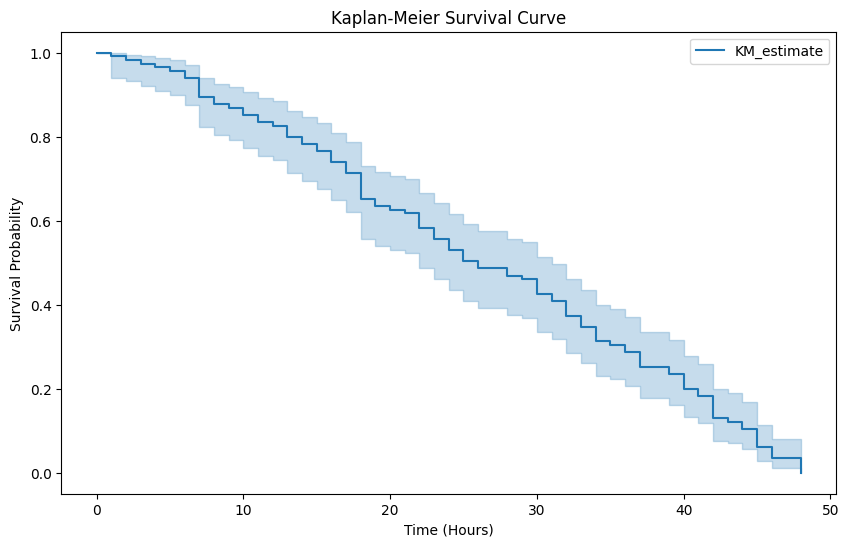

In [85]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Update the 'event_observed' column so that 1 represents failure, and 0 represents survival
main_eff_df['event_observed'] = 1 - main_eff_df['survive']  # 1 for failure, 0 for censored (survived)

# Initialize and fit the Kaplan-Meier fitter
kmf = KaplanMeierFitter()
kmf.fit(durations=main_eff_df['hour'], event_observed=main_eff_df['event_observed'])

# Plot the survival curve
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve for ")
plt.xlabel("Time (Hours)")
plt.ylabel("Survival Probability")
plt.show()


In [88]:
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter

# Define and fit Weibull AFT model
weibull_aft = WeibullAFTFitter()
weibull_aft.fit(main_eff_df, duration_col='hour', event_col='event_observed')

# Define and fit Log-Normal AFT model
lognormal_aft = LogNormalAFTFitter()
lognormal_aft.fit(main_eff_df, duration_col='hour', event_col='event_observed')

# Define and fit Log-Logistic AFT model
loglogistic_aft = LogLogisticAFTFitter()
loglogistic_aft.fit(main_eff_df, duration_col='hour', event_col='event_observed')

# Print the summary of each model for comparison
print("Weibull AFT Summary:")
print(weibull_aft.summary)
print("\nLog-Normal AFT Summary:")
print(lognormal_aft.summary)
print("\nLog-Logistic AFT Summary:")
print(loglogistic_aft.summary)


/opt/anaconda3/lib/python3.11/site-packages/lifelines/fitters/__init__.py:2086: ApproximationWarning: The Hessian was not invertible. We will instead approximate it using the pseudo-inverse.

It's advisable to not trust the variances reported, and to be suspicious of the fitted parameters too.

Some ways to possible ways fix this:

0. Are there any lifelines warnings outputted during the `fit`?
1. Does a particularly large variable need to be centered to 0?
2. Inspect your DataFrame: does everything look as expected? Do you need to add/drop a constant (intercept) column?
3. Is there high-collinearity in the dataset? Try using the variance inflation factor (VIF) to find redundant variables.
4. Trying adding a small penalizer (or changing it, if already present). Example: `WeibullAFTFitter(penalizer=0.01).fit(...)`.
5. Are there any extreme outliers? Try modeling them or dropping them to see if it helps convergence.

  warnings.warn(warning_text, exceptions.ApproximationWarning)
/opt/ana

Weibull AFT Summary:
                             coef  exp(coef)  se(coef)  coef lower 95%  \
param   covariate                                                        
lambda_ age         -1.321083e-01   0.876246  0.067041   -2.635060e-01   
        backup       2.573308e-02   1.026067  0.090374   -1.513974e-01   
        bridgecrane -1.587286e-01   0.853228  0.146753   -4.463597e-01   
        elevation   -1.028526e-01   0.902260  0.067657   -2.354579e-01   
        gear         2.163573e-01   1.241546  0.172990   -1.226973e-01   
        no_flood     3.391543e+00  29.711761       NaN             NaN   
        reason       1.580781e+00   4.858750  0.170104    1.247384e+00   
        reason2      1.580781e+00   4.858750  0.170104    1.247384e+00   
        servo        2.143407e-01   1.239045  0.094933    2.827460e-02   
        slope       -1.412157e-02   0.985978  0.012480   -3.858247e-02   
        survive     -1.737822e-17   1.000000  0.000000   -1.737822e-17   
        trashrack

/opt/anaconda3/lib/python3.11/site-packages/lifelines/fitters/__init__.py:2086: ApproximationWarning: The Hessian was not invertible. We will instead approximate it using the pseudo-inverse.

It's advisable to not trust the variances reported, and to be suspicious of the fitted parameters too.

Some ways to possible ways fix this:

0. Are there any lifelines warnings outputted during the `fit`?
1. Does a particularly large variable need to be centered to 0?
2. Inspect your DataFrame: does everything look as expected? Do you need to add/drop a constant (intercept) column?
3. Is there high-collinearity in the dataset? Try using the variance inflation factor (VIF) to find redundant variables.
4. Trying adding a small penalizer (or changing it, if already present). Example: `LogLogisticAFTFitter(penalizer=0.01).fit(...)`.
5. Are there any extreme outliers? Try modeling them or dropping them to see if it helps convergence.

  warnings.warn(warning_text, exceptions.ApproximationWarning)
/opt

/var/folders/2g/7wbchb2s0wvgd6gwy4w7vlch0000gn/T/ipykernel_4971/2480113078.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_eff_df['event_observed'] = 1 - main_eff_df['survive']  # 1 for failure, 0 for censored


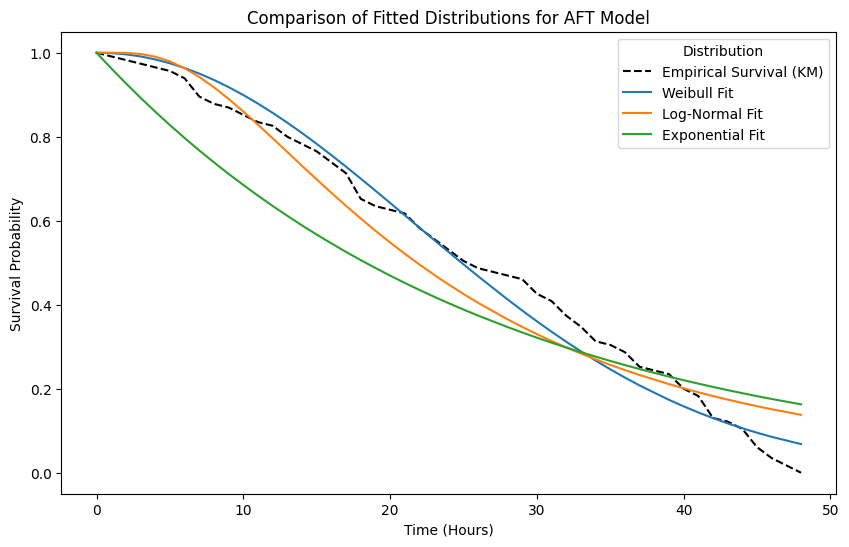

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import weibull_min, lognorm, expon

# Assume `main_eff_df` contains 'hour' for duration and 'survive' where 0 is failure and 1 is censored
main_eff_df['event_observed'] = 1 - main_eff_df['survive']  # 1 for failure, 0 for censored

# Fit the Kaplan-Meier estimator to get the empirical survival function
kmf = KaplanMeierFitter()
kmf.fit(durations=main_eff_df['hour'], event_observed=main_eff_df['event_observed'])

# Extract time and survival probabilities from Kaplan-Meier
time = kmf.survival_function_.index
empirical_survival = kmf.survival_function_['KM_estimate']

# Plot the Kaplan-Meier survival curve
plt.figure(figsize=(10, 6))
plt.plot(time, empirical_survival, label="Empirical Survival (KM)", color="black", linestyle="--")

# Fit Weibull distribution to the data
c, loc, scale = weibull_min.fit(main_eff_df['hour'][main_eff_df['event_observed'] == 1], floc=0)
weibull_survival = weibull_min.sf(time, c, loc=loc, scale=scale)
plt.plot(time, weibull_survival, label="Weibull Fit")

# Fit Log-Normal distribution to the data
shape, loc, scale = lognorm.fit(main_eff_df['hour'][main_eff_df['event_observed'] == 1], floc=0)
lognorm_survival = lognorm.sf(time, shape, loc=loc, scale=scale)
plt.plot(time, lognorm_survival, label="Log-Normal Fit")

# Fit Exponential distribution to the data
loc, scale = expon.fit(main_eff_df['hour'][main_eff_df['event_observed'] == 1], floc=0)
expon_survival = expon.sf(time, loc=loc, scale=scale)
plt.plot(time, expon_survival, label="Exponential Fit")

# Customize the plot
plt.title("Comparison of Fitted Distributions for AFT Model")
plt.xlabel("Time (Hours)")
plt.ylabel("Survival Probability")
plt.legend(title="Distribution")
plt.show()


Anderson-Darling statistic for Exponential (proxy for Weibull): 10.954624409290858
Critical Values: [0.917 1.072 1.334 1.598 1.947]
Significance Level: [15.  10.   5.   2.5  1. ]


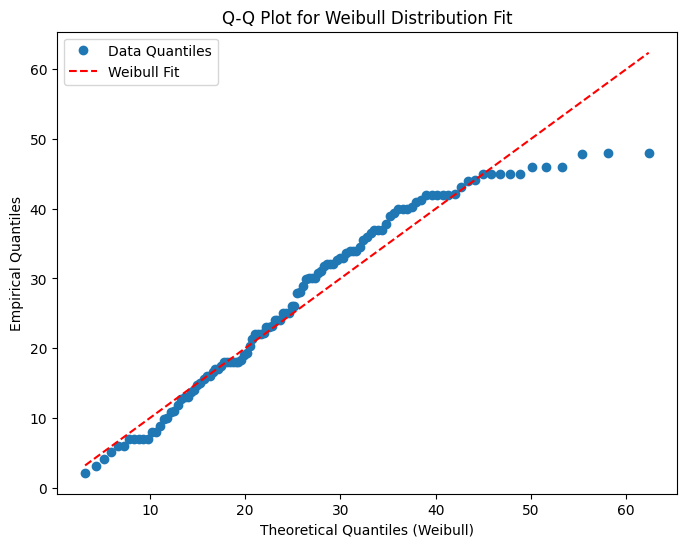

In [94]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# Extract the durations for uncensored events (failures)
data = main_eff_df['hour'][main_eff_df['event_observed'] == 1]

# Fit the Weibull distribution to the data
c, loc, scale = stats.weibull_min.fit(data, floc=0)

# 1. Anderson-Darling test for Weibull distribution (as a proxy using Exponential test)
# Note: If necessary, use a larger sample size, as this can be sample-size sensitive
ad_statistic, critical_values, significance_level = stats.anderson(data, dist='expon')
print(f"Anderson-Darling statistic for Exponential (proxy for Weibull): {ad_statistic}")
print(f"Critical Values: {critical_values}")
print(f"Significance Level: {significance_level}")

# 2. Q-Q plot for Weibull Distribution
weibull_quantiles = np.linspace(0.01, 0.99, len(data))
theoretical_quantiles = stats.weibull_min.ppf(weibull_quantiles, c, loc=loc, scale=scale)
sample_quantiles = np.quantile(data, weibull_quantiles)

plt.figure(figsize=(8, 6))
plt.plot(theoretical_quantiles, sample_quantiles, 'o', label="Data Quantiles")
plt.plot([min(theoretical_quantiles), max(theoretical_quantiles)],
         [min(theoretical_quantiles), max(theoretical_quantiles)],
         'r--', label="Weibull Fit")
plt.xlabel("Theoretical Quantiles (Weibull)")
plt.ylabel("Empirical Quantiles")
plt.title("Q-Q Plot for Weibull Distribution Fit")
plt.legend()
plt.show()


In [95]:
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter

# Prepare data for AFT fitting
aft_data = main_eff_df[['hour', 'event_observed']]

# Fit Weibull AFT model
weibull_aft = WeibullAFTFitter()
weibull_aft.fit(aft_data, duration_col='hour', event_col='event_observed')
print("Weibull AFT Model Summary:")
print(weibull_aft.summary)

# Compare with Log-Normal AFT model
lognormal_aft = LogNormalAFTFitter()
lognormal_aft.fit(aft_data, duration_col='hour', event_col='event_observed')
print("Log-Normal AFT Model Summary:")
print(lognormal_aft.summary)

# Compare with Log-Logistic AFT model
loglogistic_aft = LogLogisticAFTFitter()
loglogistic_aft.fit(aft_data, duration_col='hour', event_col='event_observed')
print("Log-Logistic AFT Model Summary:")
print(loglogistic_aft.summary)



Weibull AFT Model Summary:
                       coef  exp(coef)  se(coef)  coef lower 95%  \
param   covariate                                                  
lambda_ Intercept  3.391543  29.711768  0.047346        3.298747   
rho_    Intercept  0.722585   2.059751  0.078155        0.569404   

                   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
param   covariate                                                             
lambda_ Intercept        3.484340            27.078675            32.600900   
rho_    Intercept        0.875766             1.767213             2.400714   

                   cmp to          z             p   -log2(p)  
param   covariate                                              
lambda_ Intercept     0.0  71.632972  0.000000e+00        inf  
rho_    Intercept     0.0   9.245529  2.340797e-20  65.211562  
Log-Normal AFT Model Summary:
                      coef  exp(coef)  se(coef)  coef lower 95%  \
param  covariate              

In [97]:
from lifelines import WeibullAFTFitter, LogNormalAFTFitter
import pandas as pd

# Fit a Weibull AFT model
weibull_aft = WeibullAFTFitter()
weibull_aft.fit(main_eff_df, duration_col='hour', event_col='event_observed')
print("Weibull AFT AIC:", weibull_aft.AIC_)

# Fit a Log-normal AFT model
lognormal_aft = LogNormalAFTFitter()
lognormal_aft.fit(main_eff_df, duration_col='hour', event_col='event_observed')
print("Log-normal AFT AIC:", lognormal_aft.AIC_)

# Compare with Log-Logistic AFT model
loglogistic_aft = LogLogisticAFTFitter()
loglogistic_aft.fit(aft_data, duration_col='hour', event_col='event_observed')
print("Log-Logistic AFT Model AIC:", loglogistic_aft.AIC_)

/opt/anaconda3/lib/python3.11/site-packages/lifelines/fitters/__init__.py:2086: ApproximationWarning: The Hessian was not invertible. We will instead approximate it using the pseudo-inverse.

It's advisable to not trust the variances reported, and to be suspicious of the fitted parameters too.

Some ways to possible ways fix this:

0. Are there any lifelines warnings outputted during the `fit`?
1. Does a particularly large variable need to be centered to 0?
2. Inspect your DataFrame: does everything look as expected? Do you need to add/drop a constant (intercept) column?
3. Is there high-collinearity in the dataset? Try using the variance inflation factor (VIF) to find redundant variables.
4. Trying adding a small penalizer (or changing it, if already present). Example: `WeibullAFTFitter(penalizer=0.01).fit(...)`.
5. Are there any extreme outliers? Try modeling them or dropping them to see if it helps convergence.

  warnings.warn(warning_text, exceptions.ApproximationWarning)
/opt/ana

Weibull AFT AIC: 932.6461209353631
Log-normal AFT AIC: 970.4467549469667
Log-Logistic AFT Model AIC: 955.1321517268292


/opt/anaconda3/lib/python3.11/site-packages/lifelines/fitters/__init__.py:2086: ApproximationWarning: The Hessian was not invertible. We will instead approximate it using the pseudo-inverse.

It's advisable to not trust the variances reported, and to be suspicious of the fitted parameters too.

Some ways to possible ways fix this:

0. Are there any lifelines warnings outputted during the `fit`?
1. Does a particularly large variable need to be centered to 0?
2. Inspect your DataFrame: does everything look as expected? Do you need to add/drop a constant (intercept) column?
3. Is there high-collinearity in the dataset? Try using the variance inflation factor (VIF) to find redundant variables.
4. Trying adding a small penalizer (or changing it, if already present). Example: `LogNormalAFTFitter(penalizer=0.01).fit(...)`.
5. Are there any extreme outliers? Try modeling them or dropping them to see if it helps convergence.

  warnings.warn(warning_text, exceptions.ApproximationWarning)


Weibull is the best by AIC. Let's check which variables are significant via regularized regression, then build the AFT with a Weibull distribution.

In [101]:
from lifelines import WeibullAFTFitter
import pandas as pd

# Assuming `main_eff_df` is your DataFrame with 'hours' and 'survive' columns,
# and additional covariates for the model (e.g., 'covariate1', 'covariate2', etc.)

# Initialize the Weibull AFT model
aft_model = WeibullAFTFitter()

# Fit the model on your data
aft_model.fit(main_eff_df, duration_col='hour', event_col='event_observed')

# Print model summary for coefficients and model details
print(f"Model Summary: {aft_model.summary}")
print(f"AIC: {aft_model.AIC_}")


Model Summary:                              coef  exp(coef)  se(coef)  coef lower 95%  \
param   covariate                                                        
lambda_ age         -1.321083e-01   0.876246  0.067041   -2.635060e-01   
        backup       2.573308e-02   1.026067  0.090374   -1.513974e-01   
        bridgecrane -1.587286e-01   0.853228  0.146753   -4.463597e-01   
        elevation   -1.028526e-01   0.902260  0.067657   -2.354579e-01   
        gear         2.163573e-01   1.241546  0.172990   -1.226973e-01   
        no_flood     3.391543e+00  29.711761       NaN             NaN   
        reason       1.580781e+00   4.858750  0.170104    1.247384e+00   
        reason2      1.580781e+00   4.858750  0.170104    1.247384e+00   
        servo        2.143407e-01   1.239045  0.094933    2.827460e-02   
        slope       -1.412157e-02   0.985978  0.012480   -3.858247e-02   
        survive     -1.737822e-17   1.000000  0.000000   -1.737822e-17   
        trashrack   -2.

/opt/anaconda3/lib/python3.11/site-packages/lifelines/fitters/__init__.py:2086: ApproximationWarning: The Hessian was not invertible. We will instead approximate it using the pseudo-inverse.

It's advisable to not trust the variances reported, and to be suspicious of the fitted parameters too.

Some ways to possible ways fix this:

0. Are there any lifelines warnings outputted during the `fit`?
1. Does a particularly large variable need to be centered to 0?
2. Inspect your DataFrame: does everything look as expected? Do you need to add/drop a constant (intercept) column?
3. Is there high-collinearity in the dataset? Try using the variance inflation factor (VIF) to find redundant variables.
4. Trying adding a small penalizer (or changing it, if already present). Example: `WeibullAFTFitter(penalizer=0.01).fit(...)`.
5. Are there any extreme outliers? Try modeling them or dropping them to see if it helps convergence.

  warnings.warn(warning_text, exceptions.ApproximationWarning)
/opt/ana

In [ ]:
#methods

#### HW3
- variable selection, with regularized regression setting in CPH
- checking assumptions: linearity (martingale resids), schoenfeld for PH, 
- then create the long dataset
- then check the p-value for the new consechours variable
- hour level: counting process (to remove immortal bias)
- CPH on the hourly

- filter for failure type = 2
- use reason = 2 as my event column, don't chop the dataset

In [1]:
import pandas as pd

Get Data - base df, to check for variable significance

In [57]:
import pandas as pd
from lifelines import CoxPHFitter

# Load your dataset (replace with your data)
# Assume `df` is a DataFrame with time, event, and covariates
# 'time' = duration, 'event' = binary outcome (1 = event, 0 = censored)
df = pd.read_csv("hurricane.csv")


In [58]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

# Load the data
df = pd.read_csv("hurricane.csv")

# Remove columns matching h1 to h48, and other specified columns
cols_to_remove = [f"h{i}" for i in range(1, 49)] + ["reason2", "survive", "trashrack"]
df2 = df.drop(columns=[col for col in cols_to_remove if col in df.columns])


In [59]:
# Create a new binary column where 1 indicates reason == 2
df2['reason_binary'] = (df2['reason'] == 2).astype(int)

# Cox Proportional Hazards Model - Backward selection (approximation in Python)
cph = CoxPHFitter()
cph.fit(df2, duration_col="hour", event_col="reason_binary")

<lifelines.CoxPHFitter: fitted with 770 total observations, 658 right-censored observations>

In [60]:

# For backward selection, there isn't an automatic backward selection in Python like R.
# It must be implemented manually or use a library like `statsmodels` for stepwise regression.
# Here, assume we manually identify variables to keep.

# Variables to keep based on backward selection
selected_vars = ["servo", "age", "slope", "backup"]

# Check linearity
# For linearity checks, you'd need to visualize residuals or use other statistical methods.
# CoxPHFitter doesn't have a direct ggcoxfunctional equivalent, so you would create custom visualizations.

# Transform `slope` and `age` into categories based on knots
df3 = df2.copy()
df3["slope"] = np.select(
    [df3["slope"] <= 3, df3["slope"] <= 5, df3["slope"] >= 10],
    [0, 1, 2],
    default=np.nan
)
df3["age"] = np.select(
    [df3["age"] < 7, df3["age"] < 9, df3["age"] >= 9],
    [0, 1, 2],
    default=np.nan
)

df3.head()


,backup,age,bridgecrane,servo,gear,slope,elevation,hour,reason,reason_binary
0,0,0.0,0,0,0,0.0,2,48,0,0
1,0,0.0,1,0,0,NaN,3,48,0,0
2,0,0.0,1,0,0,0.0,3,48,0,0
3,1,0.0,1,0,0,1.0,3,48,0,0
4,0,0.0,1,1,0,0.0,4,48,0,0


(array([352.,   0.,   0.,   0.,   0., 359.,   0.,   0.,   0.,  59.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

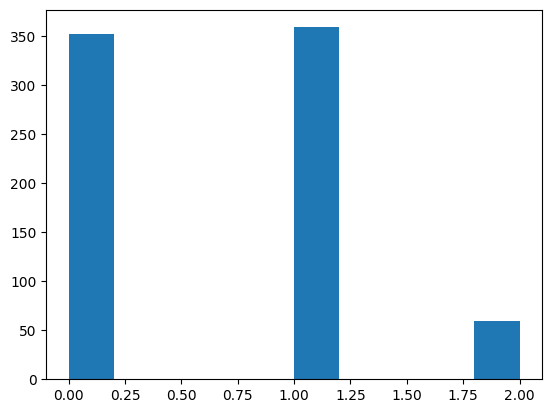

In [63]:
import matplotlib.pyplot as plt
plt.hist(df3.age)

In [22]:
df3.shape

(770, 10)

In [42]:
# Drop rows with missing values in the relevant columns for the Cox model
df3_cleaned = df3.dropna(subset=["hour", "reason_binary", "servo", "age", "slope"])

# Verify shape consistency
print(f"Shape of df3 before cleaning: {df3.shape}")
print(f"Shape of df3_cleaned: {df3_cleaned.shape}")

# Fit Cox model with transformed variables
cox_model = CoxPHFitter()
cox_model.fit(df3_cleaned, duration_col="hour", event_col="reason_binary", formula="servo + age + slope")

# Check time dependency using the cleaned data
results = proportional_hazard_test(cox_model, df3_cleaned, time_transform="rank")
print(results.summary)


Shape of df3 before cleaning: (770, 10)
Shape of df3_cleaned: (711, 10)
       test_statistic         p  -log2(p)
age          0.514085  0.473376  1.078942
servo        0.001852  0.965677  0.050388
slope        2.467468  0.116225  3.105007


In [43]:

# Transform data into long format
df["id"] = range(1, len(df) + 1)

# Convert wide to long format for h1 to h48
hurricane = df.melt(
    id_vars=["id", "hour", "reason", "servo", "slope", "age"],
    value_vars=[f"h{i}" for i in range(1, 49)],
    var_name="stop",
    value_name="pumpon"
)


In [44]:
hurricane.isna().mean()

id        0.00000
hour      0.00000
reason    0.00000
servo     0.00000
slope     0.00000
age       0.00000
stop      0.00000
pumpon    0.10744
dtype: float64

In [45]:
hurricane[["servo", "age", "slope", "reason", "pumpon"]] = hurricane[["servo", "age", "slope", "reason", "pumpon"]].fillna(0).replace([np.inf, -np.inf], 0).astype(int)

In [46]:
hurricane.isna().mean()

id        0.0
hour      0.0
reason    0.0
servo     0.0
slope     0.0
age       0.0
stop      0.0
pumpon    0.0
dtype: float64

In [47]:
hurricane.head()

,id,hour,reason,servo,slope,age,stop,pumpon
0,1,48,0,0,3,6,h1,1
1,2,48,0,0,7,6,h1,0
2,3,48,0,0,3,6,h1,0
3,4,48,0,0,4,6,h1,1
4,5,48,0,1,3,6,h1,1


In [48]:

# Additional transformations
hurricane["stop"] = hurricane["stop"].astype(str).str.extract("(\d+)").astype(int)
hurricane["start"] = hurricane["stop"] - 1
hurricane["twelve_hours"] = (
    hurricane.groupby("id")["pumpon"]
    .apply(lambda x: x.rolling(window=12, min_periods=12).sum() == 12)
    .reset_index(drop=True)
    .astype(int)
)
hurricane = hurricane[hurricane["stop"] <= hurricane["hour"]]
hurricane["reason"] = np.where(hurricane["hour"] == hurricane["stop"], hurricane["reason"], 0)
hurricane["slope"] = np.select(
    [hurricane["slope"] <= 3, hurricane["slope"] <= 5, hurricane["slope"] >= 10],
    [0, 1, 2],
    default=np.nan
)
hurricane["age"] = np.select(
    [hurricane["age"] < 7, hurricane["age"] < 9, hurricane["age"] >= 9],
    [0, 1, 2],
    default=np.nan
)
hurricane[["servo", "age", "slope", "reason", "pumpon", "twelve_hours"]] = hurricane[["servo", "age", "slope", "reason", "pumpon", "twelve_hours"]].fillna(0).replace([np.inf, -np.inf], 0).astype(int)

hurricane[["servo", "age", "slope", "reason", "pumpon", "twelve_hours"]] = hurricane[["servo", "age", "slope", "reason", "pumpon", "twelve_hours"]].astype(int)

hurricane["slope_tt"] = hurricane["slope"] * hurricane["start"]


In [49]:
hurricane.dropna(subset=["start", "reason", "servo", "age", "slope", "twelve_hours", "slope_tt"], inplace=True)

In [50]:
hurricane.isna().mean()

id              0.0
hour            0.0
reason          0.0
servo           0.0
slope           0.0
age             0.0
stop            0.0
pumpon          0.0
start           0.0
twelve_hours    0.0
slope_tt        0.0
dtype: float64

In [51]:
hurricane.tail(25)

,id,hour,reason,servo,slope,age,stop,pumpon,start,twelve_hours,slope_tt
36500,311,48,0,1,0,2,48,1,47,1,0
36501,312,48,0,1,0,2,48,1,47,1,0
36502,313,48,0,1,0,2,48,1,47,1,0
36503,314,48,0,1,0,2,48,1,47,1,0
36504,315,48,0,1,0,2,48,1,47,1,0
36505,316,48,0,0,0,2,48,0,47,1,0
36550,361,48,1,0,0,0,48,0,47,0,0
36578,389,48,1,1,0,1,48,0,47,0,0
36581,392,48,1,1,0,1,48,0,47,0,0
36615,426,48,1,1,0,1,48,1,47,0,0


In [52]:
hurricane.drop(columns={'slope'}, inplace=True)
hurricane.columns

Index(['id', 'hour', 'reason', 'servo', 'age', 'stop', 'pumpon', 'start',
       'twelve_hours', 'slope_tt'],
      dtype='object')

In [54]:


# Fit a Cox model for the long-format data
hurricane_cph = CoxPHFitter()
hurricane_cph.fit(
    hurricane,
    duration_col="start",
    event_col="reason",
    formula="servo + twelve_hours"
)

<lifelines.CoxPHFitter: fitted with 29661 total observations, 29207 right-censored observations>

In [55]:
hurricane_cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
servo,-0.222449,0.800556,0.095251,-0.409137,-0.035761,0.664223,0.964871,0.0,-2.335405,0.019522,5.678733
twelve_hours,-0.337370,0.713645,0.126843,-0.585977,-0.088763,0.556562,0.915063,0.0,-2.659749,0.007820,6.998637


<Axes: >

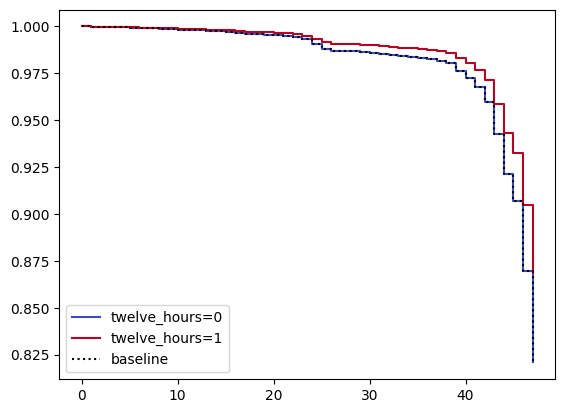

In [56]:
hurricane_cph.plot_partial_effects_on_outcome(covariates='twelve_hours', values=[0,1], cmap='coolwarm')